<a href="https://colab.research.google.com/github/geethikasri-sirikonda24/MDS_LAB/blob/main/Week_3_MDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

file_path = '/content/10db8dd3-5348-4dbc-ae5a-2920fd1e263e.csv'
df = pd.read_csv(file_path)
print(df)

     _id  Year        Jan        Feb       Mar      April        May  \
0      1  1901  10.112927  52.862372  7.168071  75.917375  32.831126   
1      2  1902   0.240396   0.000000  1.652090   8.938205   7.725327   
2      3  1903   9.087042   0.000000  0.000000   9.145082  72.514370   
3      4  1904   0.000000   0.000000  8.360287   6.717636  33.226691   
4      5  1905   0.000000   1.681273  9.383354  13.284002  73.832949   
..   ...   ...        ...        ...       ...        ...        ...   
116  117  2017   0.000000   0.000000  7.111951  18.481173  30.193530   
117  118  2018   0.000000   0.000000  1.379888  33.635686  60.990646   
118  119  2019  14.167822   0.530879  0.369189  20.313522  34.606489   
119  120  2020   2.456763   6.358386  7.971729  22.438614  14.578018   
120  121  2021   0.736121   1.718592  0.000000  12.132312  59.595728   

           June        July         Aug        Sept         Oct        Nov  \
0     83.528905  188.379469  119.180072   44.675581   88.

In [ ]:
# Install OpenCV if you haven't already
# You might need to restart the runtime after installation
!pip install opencv-python

Original image shape: (640, 480, 3)


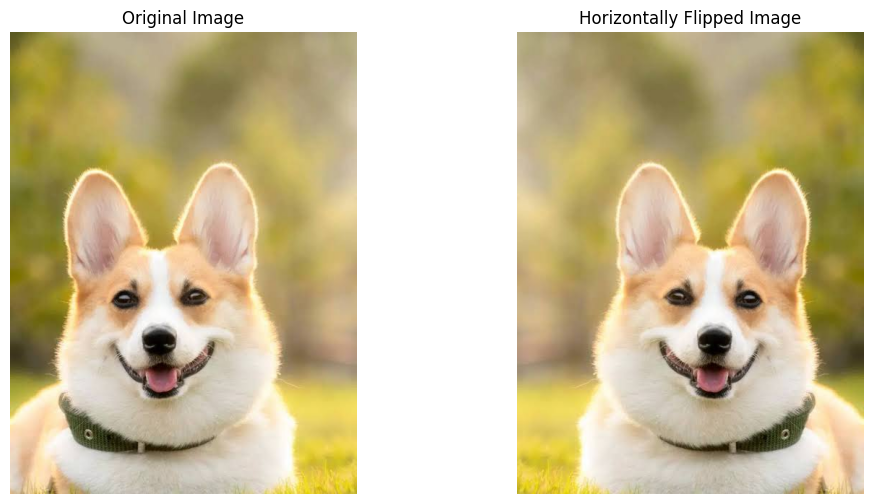

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Manually specify the path to your image file
img_path = '/content/Dog (1).jpg' # The image you specified

# Load the image using cv2
img_bgr = cv2.imread(img_path)

# Check if image was loaded successfully
if img_bgr is None:
    print(f"Error: Could not load image from {img_path}")
else:
    # Convert BGR to RGB for consistent display with matplotlib
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    print(f"Original image shape: {img_rgb.shape}")

    # Perform a horizontal flip using cv2.flip
    # The second argument (1) means horizontal flip (LEFT-RIGHT)
    flipped_img = cv2.flip(img_rgb, 1)

    # Display the original and flipped images
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(flipped_img)
    plt.title('Horizontally Flipped Image')
    plt.axis('off')

    plt.show()

Please upload an image file:


Saving Dog.jpg to Dog (1).jpg
Original image shape: (640, 480, 3)


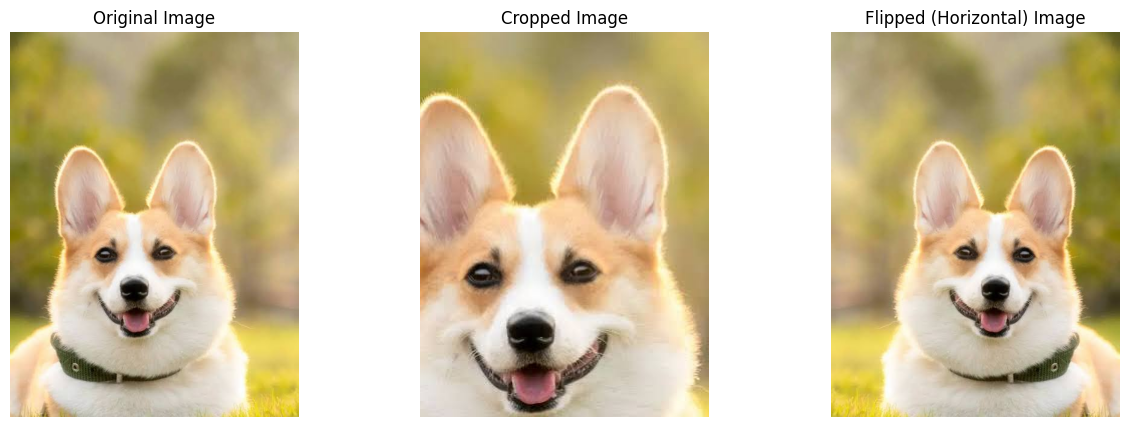

In [ ]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 1. Upload an image file
print("Please upload an image file:")
uploaded = files.upload()

# Get the filename of the uploaded image
for filename in uploaded.keys():
    img_path = filename
    break

# 2. Load the image
img = Image.open(img_path)
img_array = np.array(img)

print(f"Original image shape: {img_array.shape}")

# 3. Crop operation using NumPy indexing
# Define crop dimensions (e.g., crop 20% from each side)
height, width, _ = img_array.shape
top = int(height * 0.2)
bottom = height - int(height * 0.2)
left = int(width * 0.2)
right = width - int(width * 0.2)

cropped_img_array = img_array[top:bottom, left:right]

# 4. Flip operation using NumPy indexing
# Flip horizontally (left-right)
flipped_img_array = img_array[:, ::-1]

# You can also flip vertically (top-bottom) like this:
# flipped_img_array_vertical = img_array[::-1, :]

# 5. Display the original, cropped, and flipped images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_array)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cropped_img_array)
plt.title('Cropped Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(flipped_img_array)
plt.title('Flipped (Horizontal) Image')
plt.axis('off')

plt.show()

Found 2 potential faces. Searching for eyes...
Found 6 eyes.


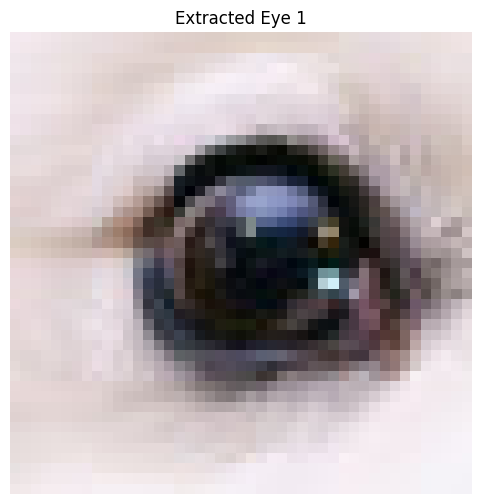

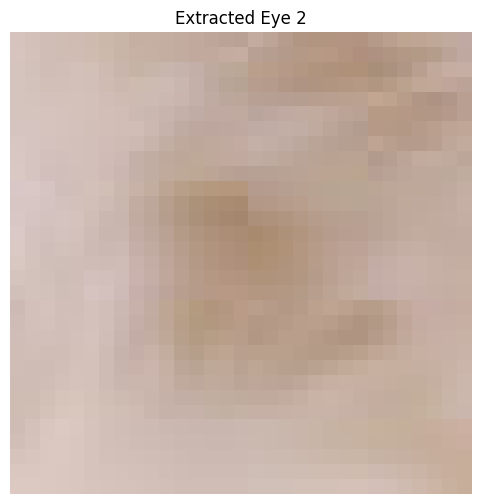

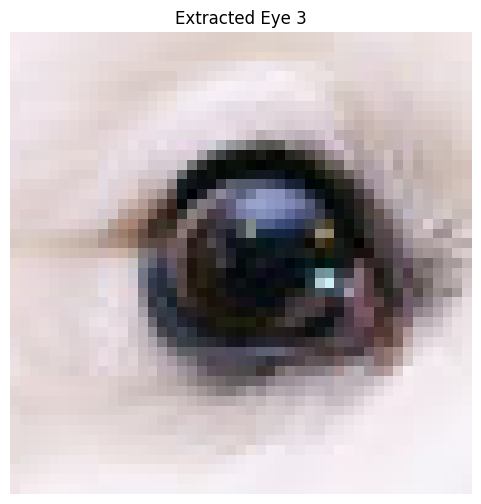

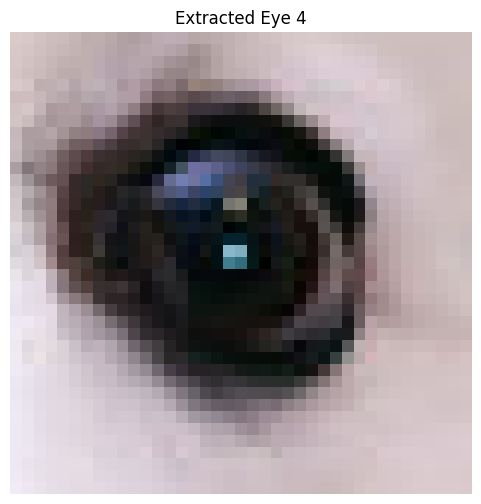

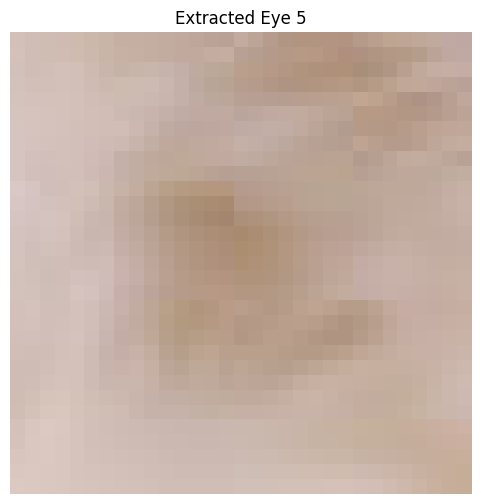

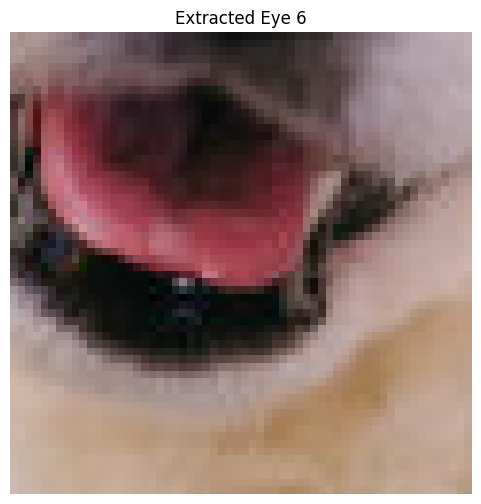

In [27]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Manually specify the path to your image file
img_path = '/content/Dog(white).jpg'

# Load the image
img_bgr = cv2.imread(img_path)

if img_bgr is None:
    print(f"Error: Could not load image from {img_path}")
else:
    # Convert BGR to RGB for display with matplotlib and to grayscale for detection
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Load the Haar cascade classifiers
    face_cascade = cv2.CascadeClassifier('haarcascade_frontalcatface.xml')
    eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')

    if face_cascade.empty() or eye_cascade.empty():
        print("Error: Haar cascade XML files not loaded. Make sure they are in the correct path or download them.")
    else:
        # Detect faces in the grayscale image with more aggressive parameters
        # Lowering scaleFactor and minNeighbors makes detection more permissive,
        # increasing chances of detection but also false positives.
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.02, minNeighbors=1, minSize=(20, 20))

        eyes_found = []

        if len(faces) == 0:
            print("No faces detected.")
        else:
            print(f"Found {len(faces)} potential faces. Searching for eyes...")
            for (x, y, w, h) in faces:
                # Region of Interest (ROI) for face in grayscale and color
                roi_gray = gray[y:y+h, x:x+w]
                roi_color = img_rgb[y:y+h, x:x+w]

                # Detect eyes within the face ROI
                eyes = eye_cascade.detectMultiScale(roi_gray, scaleFactor=1.05, minNeighbors=5, minSize=(10, 10))

                for (ex, ey, ew, eh) in eyes:
                    # Crop the eye region from the color ROI
                    eye_img = roi_color[ey:ey+eh, ex:ex+ew]
                    eyes_found.append(eye_img)

            if eyes_found:
                print(f"Found {len(eyes_found)} eyes.")
                # Display each found eye with higher resolution
                for i, eye in enumerate(eyes_found):
                    plt.figure(figsize=(6, 6)) # Increased figsize for higher resolution
                    plt.imshow(eye)
                    plt.title(f'Extracted Eye {i+1}')
                    plt.axis('off')
                    plt.show()
            else:
                print("No eyes were detected within the found faces.")

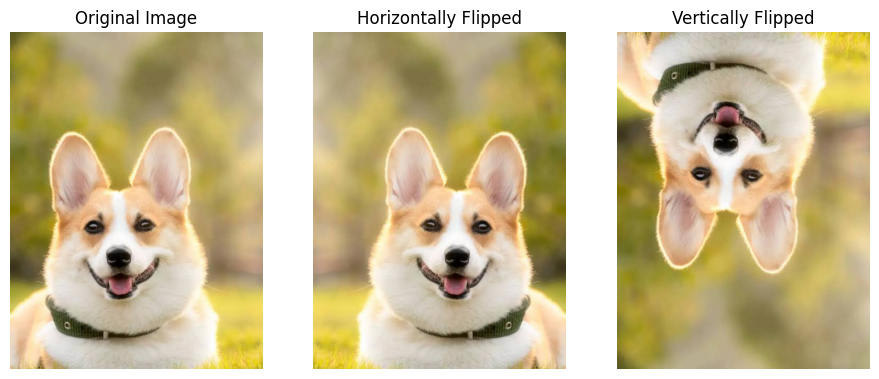

In [15]:
import cv2
import matplotlib.pyplot as plt

# Manually specify the path to your image file
img_path = '/content/Dog (1).jpg'

# Load the image
img_bgr = cv2.imread(img_path)

if img_bgr is None:
    print(f"Error: Could not load image from {img_path}")
else:
    # Convert BGR to RGB for consistent display with matplotlib
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Flip vertically (TOP-BOTTOM)
    flipped_vertical = cv2.flip(img_rgb, 0)

    # Flip horizontally (LEFT-RIGHT)
    flipped_horizontal = cv2.flip(img_rgb, 1)


    # Display the original and flipped images
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(img_rgb)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(flipped_vertical)
    plt.title('Vertically Flipped')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(flipped_horizontal)
    plt.title('Horizontally Flipped')
    plt.axis('off')


    plt.show()